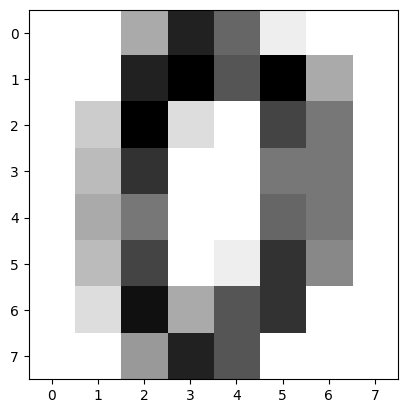

In [67]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split  # model_selection: 데이터를 훈련용과 테스트용으로 나누는 기능을 제공
from sklearn.tree import DecisionTreeClassifier       # tree: 의사결정나무 모델을 제공
from sklearn.ensemble import RandomForestClassifier   # ensemble: 여러 모델을 결합하는 앙상블 기법 (랜덤 포레스트 등)을 제공
from sklearn.linear_model import LogisticRegression   # linear_model: 선형 모델 (로지스틱 회귀 등)을 제공
from sklearn.metrics import accuracy_score            # metrics: 모델의 성능을 평가하는 다양한 지표 (정확도 등)를 제공
from sklearn.neighbors import KNeighborsClassifier    # neighbors: K-최근접 이웃(KNN) 모델을 제공
from sklearn.preprocessing import StandardScaler      # preprocessing: 데이터 전처리(스케일링 등)를 위한 기능을 제공

digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

In [68]:
n_samples = len(digits.images)

data = digits.images.reshape((n_samples, -1))

data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [69]:
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras import layers, models;

X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, random_state=42
)

In [70]:
#--------------------------
# 원-핫 인코딩
#--------------------------

from tensorflow.keras.utils import to_categorical

# y_train과 y_test를 원-핫 인코딩으로 변환
# num_classes=10은 0~9까지 10개의 클래스가 있다는 의미
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# 이제 이 y_train, y_test를 model.fit에 사용하면 됩니다.
# model.compile의 loss는 'categorical_crossentropy'를 그대로 사용합니다.

In [71]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    #layers.Dropout(0.3), # ???
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"), # 그 전까지는 relu 혹은 sigmoid 만 사용
    ## layers.Dense(1)   # 회귀일때만 사용
    layers.Dense(10, activation="softmax") # softmax는 분류할 때 사용 -> 총합 확률 1로 만드는 함수
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,938 (27.10 KB)

 Trainable params: 6,938 (27.10 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2102 - loss: 2.7918 - val_accuracy: 0.6424 - val_loss: 1.1145
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6925 - loss: 0.9740 - val_accuracy: 0.8646 - val_loss: 0.5152
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8734 - loss: 0.4611 - val_accuracy: 0.8715 - val_loss: 0.3416
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9071 - loss: 0.3107 - val_accuracy: 0.8819 - val_loss: 0.3205
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1795 - val_accuracy: 0.9306 - val_loss: 0.2437
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9638 - loss: 0.1451 - val_accuracy: 0.9306 - val_loss: 0.2021
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9709 - loss: 0.1197 - val_accuracy: 0.9271 - val_loss: 0.1953
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9788 - loss: 0.0829 - val_accuracy: 0.9479 - val_loss:

In [74]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [75]:
# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

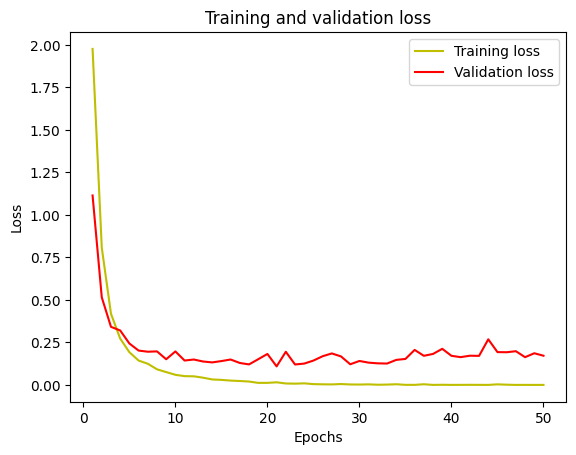

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

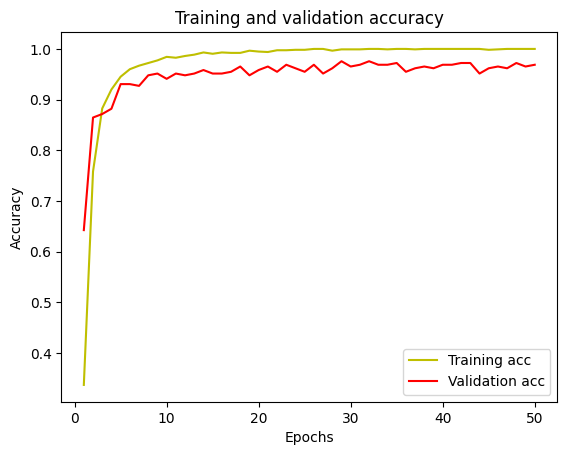

In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [78]:
model.evaluate(X_test, y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9855 - loss: 0.0839  


[0.15870895981788635, 0.9750000238418579]

In [79]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.93      0.96      0.95        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.96      0.97        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.93      0.97        30
           9       0.93      0.97      0.95        40

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.98       360

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0  0  1]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0